In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# 1. Entendimento do Negócio (Business Understanding)

Define os objetivos do projeto, o problema a ser resolvido e os critérios de sucesso sob a ótica da empresa.

# 2. Entendimento dos Dados (Data Understanding)

Coleta, explora e verifica a qualidade dos dados disponíveis para identificar insights iniciais.

In [2]:
# Carregar os dados
import pandas as pd

df = pd.read_csv('rawdata.csv')
print("Shape do dataset:", df.shape)
df.head()

Shape do dataset: (25835, 54)


,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
0,1,M,BLACK,43-47,16,No,3.0,Standard,At least some college,3 or more,...,0.000000,0.0,0.488562,0.447610,No,No,No,No,No,1
1,2,M,BLACK,33-37,16,No,6.0,Specialized,Less than HS diploma,1,...,0.000000,0.0,0.425234,2.000000,No,Yes,No,No,Yes,1
2,3,M,BLACK,48 or older,24,No,7.0,High,At least some college,3 or more,...,0.166667,0.0,0.000000,0.000000,No,Yes,No,Yes,No,1
3,4,M,WHITE,38-42,16,No,7.0,High,Less than HS diploma,1,...,0.000000,0.0,1.000000,0.718996,No,No,No,No,No,1
4,5,M,WHITE,33-37,16,No,4.0,Specialized,Less than HS diploma,3 or more,...,0.058824,0.0,0.203562,0.929389,No,Yes,Yes,No,No,1


In [3]:
# Informações sobre os dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25835 entries, 0 to 25834
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                25835 non-null  int64  
 1   Gender                            25835 non-null  str    
 2   Race                              25835 non-null  str    
 3   Age_at_Release                    25835 non-null  str    
 4   Residence_PUMA                    25835 non-null  int64  
 5   Gang_Affiliated                   22668 non-null  str    
 6   Supervision_Risk_Score_First      25360 non-null  float64
 7   Supervision_Level_First           24115 non-null  str    
 8   Education_Level                   25835 non-null  str    
 9   Dependents                        25835 non-null  str    
 10  Prison_Offense                    22558 non-null  str    
 11  Prison_Years                      25835 non-null  str    
 12  Prior_Arrest_Ep

In [4]:
# Estatísticas descritivas
df.describe(include='all')

,ID,Gender,Race,Age_at_Release,Residence_PUMA,Gang_Affiliated,Supervision_Risk_Score_First,Supervision_Level_First,Education_Level,Dependents,...,DrugTests_Meth_Positive,DrugTests_Other_Positive,Percent_Days_Employed,Jobs_Per_Year,Employment_Exempt,Recidivism_Within_3years,Recidivism_Arrest_Year1,Recidivism_Arrest_Year2,Recidivism_Arrest_Year3,Training_Sample
count,25835.000000,25835,25835,25835,25835.000000,22668,25360.000000,24115,25835,25835,...,20663.000000,20663.00000,25373.000000,25027.000000,25835,25835,25835,25835,25835,25835.000000
unique,NaN,2,2,7,NaN,2,NaN,3,3,4,...,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN
top,NaN,M,BLACK,23-27,NaN,No,NaN,Standard,High School Diploma,0,...,NaN,NaN,NaN,NaN,No,Yes,No,No,No,NaN
freq,NaN,22668,14847,5176,NaN,18730,NaN,9983,11390,8037,...,NaN,NaN,NaN,NaN,22399,14904,18111,21268,23222,NaN
mean,13314.004838,NaN,NaN,NaN,12.361796,NaN,6.082216,NaN,NaN,NaN,...,0.012890,0.00755,0.482331,0.769295,NaN,NaN,NaN,NaN,NaN,0.697813
std,7722.206327,NaN,NaN,NaN,7.133742,NaN,2.381442,NaN,NaN,NaN,...,0.060581,0.04115,0.425004,0.813787,NaN,NaN,NaN,NaN,NaN,0.459215
min,1.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,6626.500000,NaN,NaN,NaN,6.000000,NaN,4.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,13270.000000,NaN,NaN,NaN,12.000000,NaN,6.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.475728,0.635217,NaN,NaN,NaN,NaN,NaN,1.000000
75%,20021.500000,NaN,NaN,NaN,18.000000,NaN,8.000000,NaN,NaN,NaN,...,0.000000,0.00000,0.969325,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000


In [5]:
# Verificar valores ausentes
missing_values = df.isnull().sum()
print("Valores ausentes por coluna:")
print(missing_values[missing_values > 0])

# Percentual de valores ausentes
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentual de valores ausentes:")
print(missing_percent[missing_percent > 0])

Valores ausentes por coluna:
Gang_Affiliated                 3167
Supervision_Risk_Score_First     475
Supervision_Level_First         1720
Prison_Offense                  3277
Avg_Days_per_DrugTest           6103
DrugTests_THC_Positive          5172
DrugTests_Cocaine_Positive      5172
DrugTests_Meth_Positive         5172
DrugTests_Other_Positive        5172
Percent_Days_Employed            462
Jobs_Per_Year                    808
dtype: int64

Percentual de valores ausentes:
Gang_Affiliated                 12.258564
Supervision_Risk_Score_First     1.838591
Supervision_Level_First          6.657635
Prison_Offense                  12.684343
Avg_Days_per_DrugTest           23.622992
DrugTests_THC_Positive          20.019354
DrugTests_Cocaine_Positive      20.019354
DrugTests_Meth_Positive         20.019354
DrugTests_Other_Positive        20.019354
Percent_Days_Employed            1.788272
Jobs_Per_Year                    3.127540
dtype: float64


In [6]:
# Distribuição da variável alvo
print("Distribuição de Recidivism_Within_3years:")
print(df['Recidivism_Within_3years'].value_counts())
print("\nPercentual:")
print(df['Recidivism_Within_3years'].value_counts(normalize=True) * 100)

Distribuição de Recidivism_Within_3years:
Recidivism_Within_3years
Yes    14904
No     10931
Name: count, dtype: int64

Percentual:
Recidivism_Within_3years
Yes    57.689181
No     42.310819
Name: proportion, dtype: float64


In [7]:
# Verificar duplicatas
duplicates = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicates}")

# Tipos de dados únicos para colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nColunas categóricas e seus valores únicos:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} valores únicos")
    if df[col].nunique() <= 10:
        print(f"  Valores: {df[col].unique()}")

Número de linhas duplicadas: 0

Colunas categóricas e seus valores únicos:
Gender: 2 valores únicos
  Valores: <StringArray>
['M', 'F']
Length: 2, dtype: str
Race: 2 valores únicos
  Valores: <StringArray>
['BLACK', 'WHITE']
Length: 2, dtype: str
Age_at_Release: 7 valores únicos
  Valores: <StringArray>
['43-47', '33-37', '48 or older', '38-42', '18-22', '23-27', '28-32']
Length: 7, dtype: str
Gang_Affiliated: 2 valores únicos
  Valores: <StringArray>
['No', nan, 'Yes']
Length: 3, dtype: str
Supervision_Level_First: 3 valores únicos
  Valores: <StringArray>
['Standard', 'Specialized', 'High', nan]
Length: 4, dtype: str
Education_Level: 3 valores únicos
  Valores: <StringArray>
['At least some college', 'Less than HS diploma', 'High School Diploma']
Length: 3, dtype: str
Dependents: 4 valores únicos
  Valores: <StringArray>
['3 or more', '1', '0', '2']
Length: 4, dtype: str
Prison_Offense: 5 valores únicos
  Valores: <StringArray>
['Drug', 'Violent/Non-Sex', 'Property', nan, 'Other', 'V

/var/folders/4m/gng0hp257dgclj7dzphkt54c0000gn/T/ipykernel_2559/1589779261.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Converter target para numérico para análise de correlação
df['Target'] = df['Recidivism_Within_3years'].map({'Yes': 1, 'No': 0})

# Colunas numéricas (excluir ID, Training_Sample e colunas de leakage)
leak_cols = ['ID', 'Training_Sample', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']
num_cols = df.select_dtypes(include=[np.number]).columns.difference(leak_cols)

# Correlação das variáveis numéricas com o Target
corr_target = df[num_cols].corrwith(df['Target']).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
corr_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_target])
plt.title('Correlação das Variáveis Numéricas com Recidivismo')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

print("\nCorrelações com o Target:")
print(corr_target)

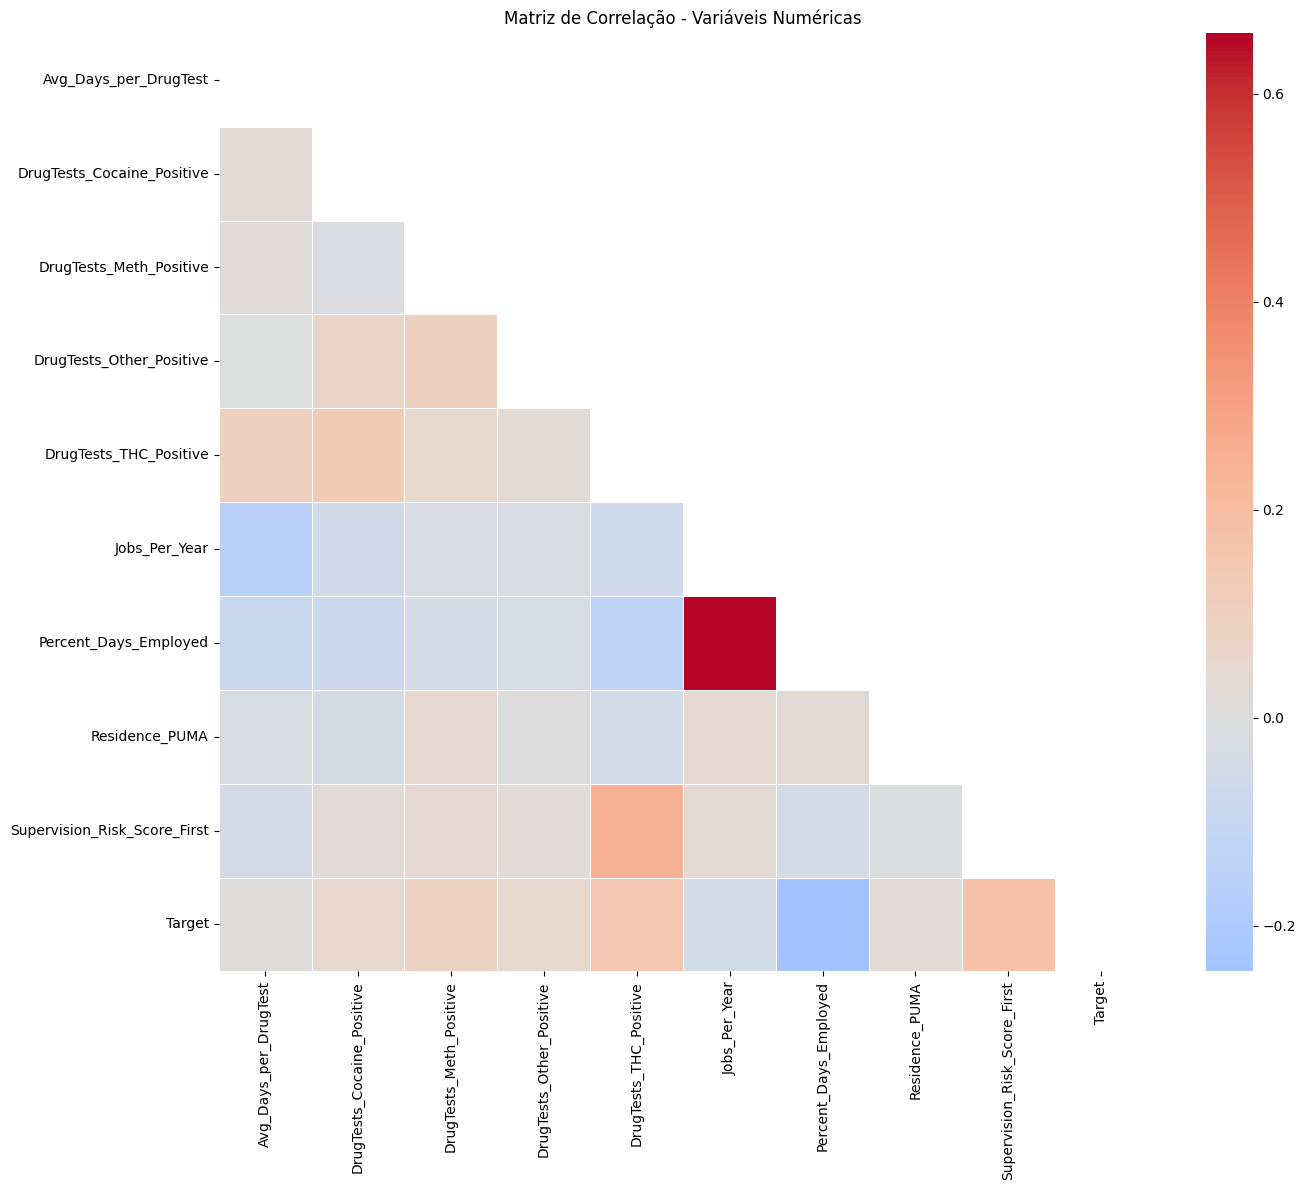

In [15]:
# Matriz de correlação das variáveis numéricas
plt.figure(figsize=(14, 12))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

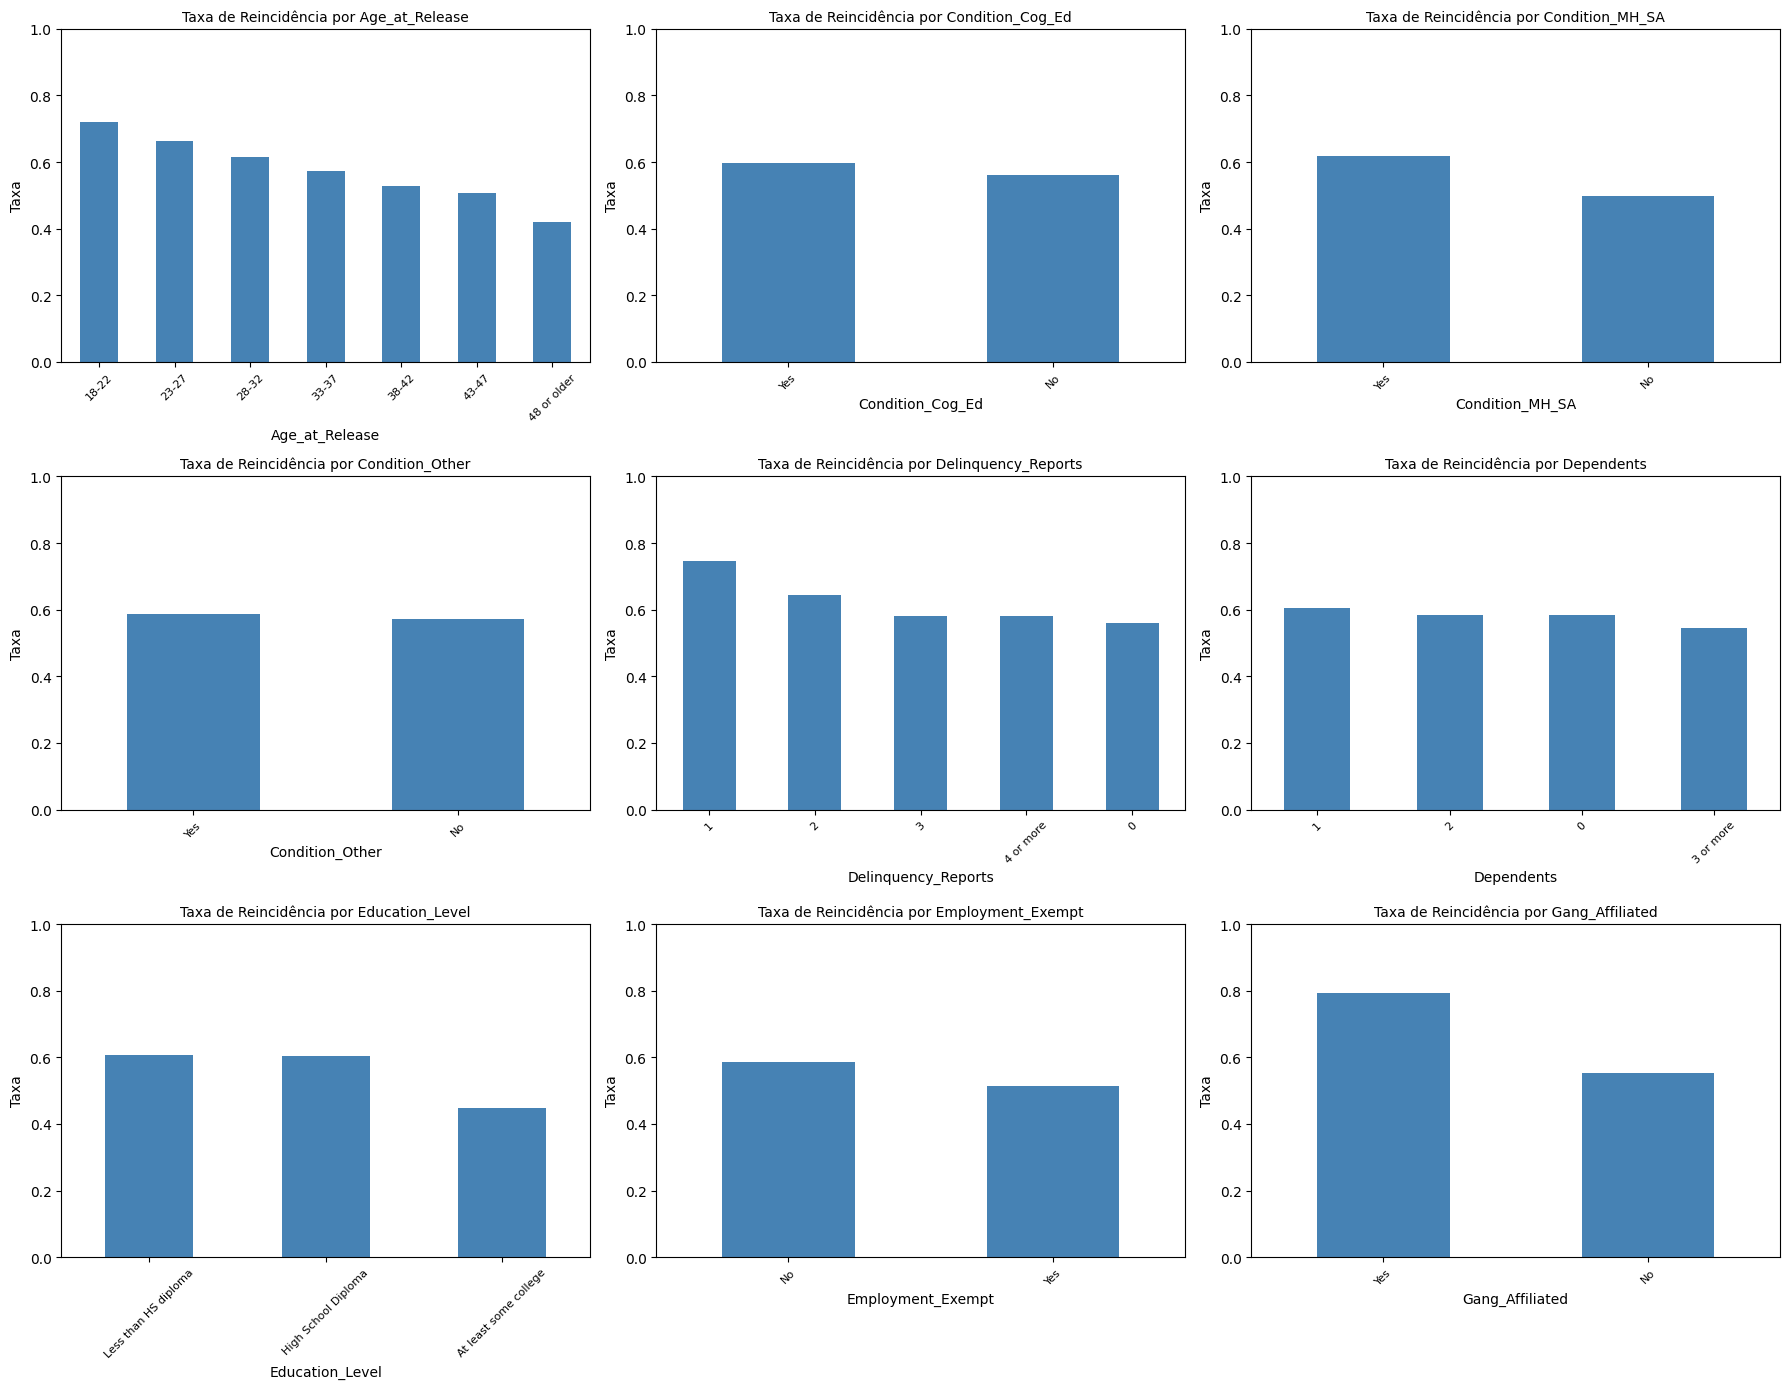

In [16]:
# Taxa de reincidência por variável categórica
cat_cols = df.select_dtypes(include=['object', 'string']).columns.difference(
    ['Recidivism_Within_3years', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3']
)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]):
    rate = df.groupby(col)['Target'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Taxa de Reincidência por {col}', fontsize=10)
    axes[i].set_ylabel('Taxa')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

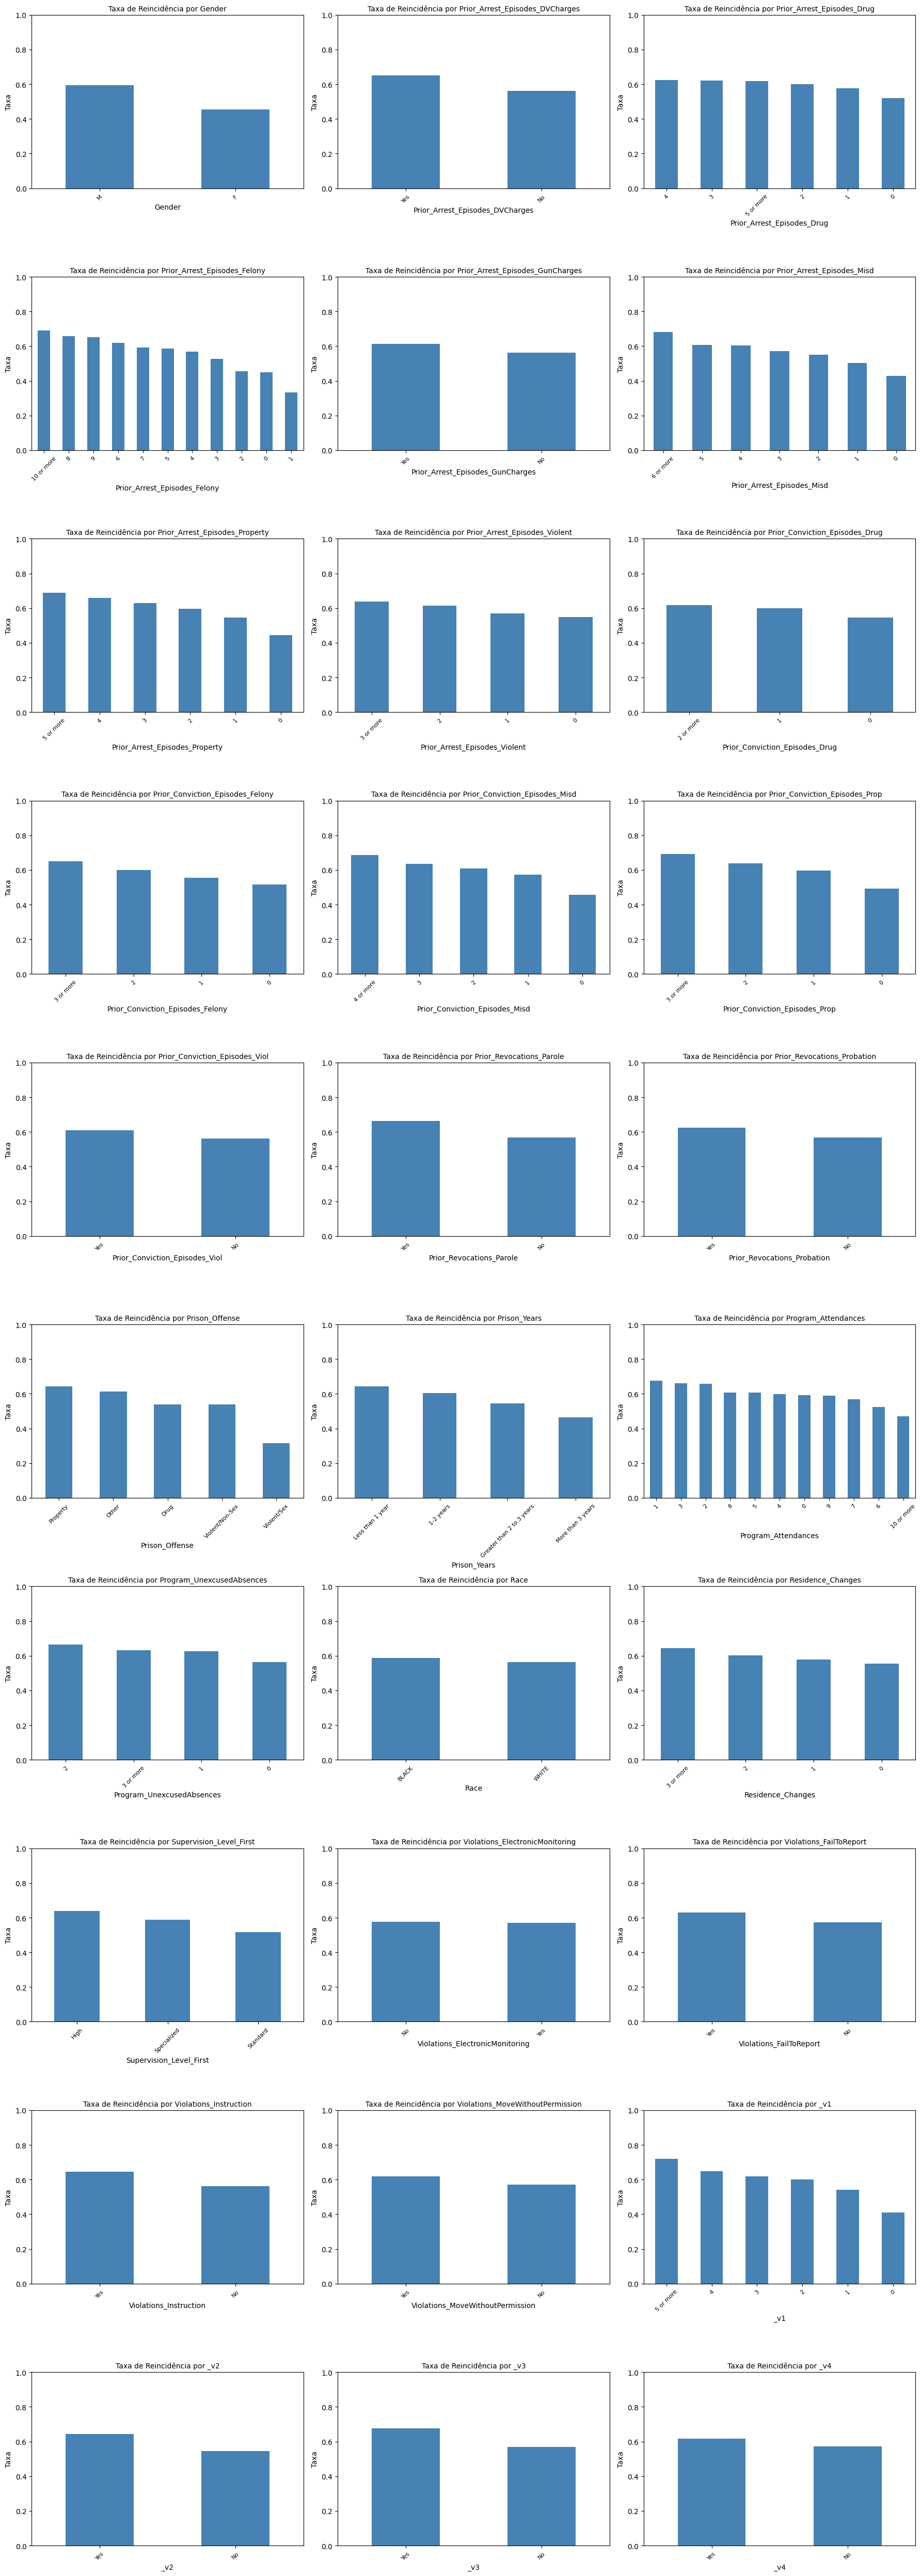

In [17]:
# Continuação - restante das variáveis categóricas
remaining_cats = cat_cols[9:]
if len(remaining_cats) > 0:
    n_plots = len(remaining_cats)
    n_rows = (n_plots + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(remaining_cats):
        rate = df.groupby(col)['Target'].mean().sort_values(ascending=False)
        rate.plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'Taxa de Reincidência por {col}', fontsize=10)
        axes[i].set_ylabel('Taxa')
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

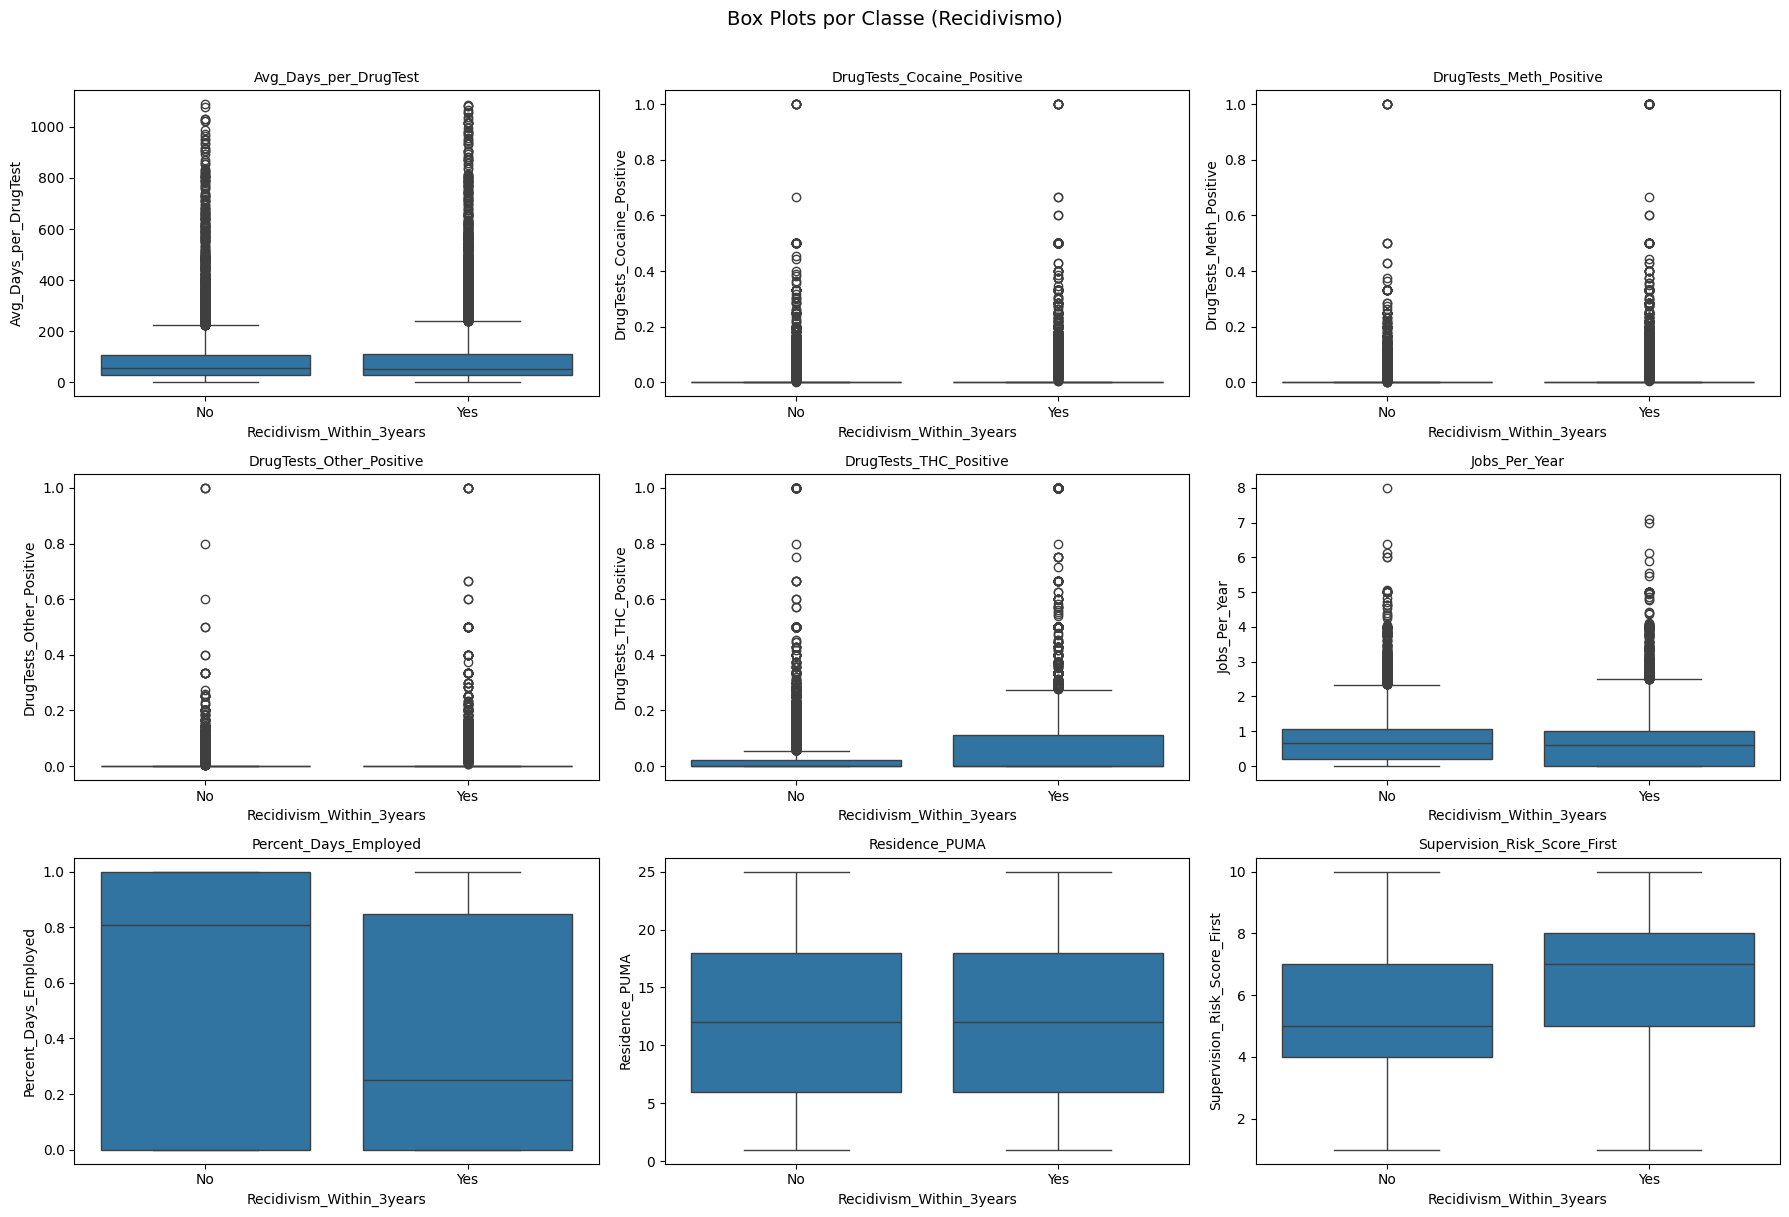

In [18]:
# Box plots das variáveis numéricas por classe (todas relevantes)
num_features = num_cols.difference(['Target'])
n_plots = len(num_features)
n_rows = (n_plots + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x='Recidivism_Within_3years', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots por Classe (Recidivismo)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 3. Preparação dos Dados (Data Preparation)

Seleciona, limpa, transforma e formata os dados para modelagem. Esta etapa costuma consumir a maior parte do tempo do projeto (60-70%).

In [22]:
# 3.1 Remover colunas irrelevantes e de data leakage
drop_cols = [
    'ID',                        # Identificador, sem valor preditivo
    'Recidivism_Arrest_Year1',   # Data leakage - informação do futuro
    'Recidivism_Arrest_Year2',   # Data leakage
    'Recidivism_Arrest_Year3',   # Data leakage
    '_v1', '_v2', '_v3', '_v4',  # Colunas sem nome claro
]

df_model = df.drop(columns=drop_cols + ['Recidivism_Within_3years', 'Target'])
print(f"Colunas removidas: {drop_cols}")
print(f"Shape após remoção: {df_model.shape}")
print(f"\nColunas restantes ({len(df_model.columns)}):")
print(df_model.columns.tolist())

Colunas removidas: ['ID', 'Recidivism_Arrest_Year1', 'Recidivism_Arrest_Year2', 'Recidivism_Arrest_Year3', '_v1', '_v2', '_v3', '_v4']
Shape após remoção: (25835, 45)

Colunas restantes (45):
['Gender', 'Race', 'Age_at_Release', 'Residence_PUMA', 'Gang_Affiliated', 'Supervision_Risk_Score_First', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', '

In [23]:
# 3.2 Separar train/test usando a coluna Training_Sample (antes de qualquer transformação)
train_mask = df['Training_Sample'] == 1
test_mask = df['Training_Sample'] == 0

X_train = df_model[train_mask].drop(columns=['Training_Sample'])
X_test = df_model[test_mask].drop(columns=['Training_Sample'])
y_train = df['Target'][train_mask]
y_test = df['Target'][test_mask]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição do target no treino:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribuição do target no teste:")
print(y_test.value_counts(normalize=True).round(3))

Treino: 18028 amostras
Teste:  7807 amostras

Distribuição do target no treino:
Target
1    0.578
0    0.422
Name: proportion, dtype: float64

Distribuição do target no teste:
Target
1    0.574
0    0.426
Name: proportion, dtype: float64


In [24]:
# 3.3 Identificar colunas categóricas e numéricas
cat_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variáveis categóricas ({len(cat_features)}): {cat_features}")
print(f"\nVariáveis numéricas ({len(num_features)}): {num_features}")

Variáveis categóricas (35): ['Gender', 'Race', 'Age_at_Release', 'Gang_Affiliated', 'Supervision_Level_First', 'Education_Level', 'Dependents', 'Prison_Offense', 'Prison_Years', 'Prior_Arrest_Episodes_Felony', 'Prior_Arrest_Episodes_Misd', 'Prior_Arrest_Episodes_Violent', 'Prior_Arrest_Episodes_Property', 'Prior_Arrest_Episodes_Drug', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Felony', 'Prior_Conviction_Episodes_Misd', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_Prop', 'Prior_Conviction_Episodes_Drug', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Delinquency_Reports', 'Program_Attendances', 'Program_UnexcusedAbsences', 'Residence_Changes', 'Employment_Exempt']

Variáveis numéricas (9): ['Residence_PUMA', 'Supervision_Risk

In [25]:
# 3.4 Tratar valores missing e encoding com Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline para variáveis numéricas: imputar com mediana + padronizar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variáveis categóricas: imputar com moda + one-hot encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Fit no treino, transform em treino e teste
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obter nomes das features após transformação
cat_encoded_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(cat_encoded_names)

print(f"Features após pré-processamento: {X_train_processed.shape[1]}")
print(f"Treino: {X_train_processed.shape}")
print(f"Teste:  {X_test_processed.shape}")
print(f"\nValores missing no treino processado: {np.isnan(X_train_processed).sum()}")
print(f"Valores missing no teste processado: {np.isnan(X_test_processed).sum()}")

ModuleNotFoundError: No module named 'sklearn'

# 4. Modelagem (Modeling)

Aplica algoritmos de machine learning (técnicas de modelagem) aos dados preparados e ajusta os parâmetros para obter o melhor desempenho.

In [ ]:
# 4.1 Regressão Logística
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_processed, y_train)

# Predições
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

print("Modelo treinado com sucesso!")
print(f"Acurácia no treino: {model.score(X_train_processed, y_train):.4f}")
print(f"Acurácia no teste:  {model.score(X_test_processed, y_test):.4f}")

# 5. Avaliação (Evaluation)

Verifica se o modelo construído atende às metas de negócio estabelecidas na primeira etapa.

In [ ]:
# 5.1 Matriz de Confusão e Classification Report
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Não Reincidente (0)', 'Reincidente (1)']))

# Plot da Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Não (0)', 'Sim (1)'], ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusão')
plt.tight_layout()
plt.show()

In [ ]:
# 5.2 Curva ROC e AUC
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Regressão Logística')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [ ]:
# 5.3 Importância das Features (Coeficientes da Regressão Logística)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': model.coef_[0]
}).sort_values('Coeficiente', ascending=True)

# Top 20 features mais importantes (maiores coeficientes absolutos)
top_features = coef_df.reindex(coef_df['Coeficiente'].abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in top_features['Coeficiente']]
plt.barh(top_features['Feature'], top_features['Coeficiente'], color=colors)
plt.xlabel('Coeficiente')
plt.title('Top 20 Features - Regressão Logística\n(Verde = aumenta chance de reincidência, Vermelho = diminui)')
plt.tight_layout()
plt.show()

# 6. Implantação (Deployment)

Coloca o modelo em produção para uso prático, o que pode incluir a criação de relatórios, ferramentas ou APIs, além de monitorar seu desempenho.

In [ ]:
# 6.1 Resumo do Modelo
print("=" * 60)
print("RESUMO DO PROJETO - PREDIÇÃO DE REINCIDÊNCIA CRIMINAL")
print("=" * 60)
print(f"\nModelo: Regressão Logística")
print(f"Total de amostras: {len(df)}")
print(f"Treino: {X_train_processed.shape[0]} | Teste: {X_test_processed.shape[0]}")
print(f"Features utilizadas: {X_train_processed.shape[1]}")
print(f"\nMétricas no conjunto de teste:")
print(f"  Acurácia: {model.score(X_test_processed, y_test):.4f}")
print(f"  AUC:      {auc_score:.4f}")
print(f"\nDistribuição real no teste:")
print(f"  Reincidentes:     {(y_test == 1).sum()} ({(y_test == 1).mean():.1%})")
print(f"  Não reincidentes: {(y_test == 0).sum()} ({(y_test == 0).mean():.1%})")
print(f"\nTop 5 fatores que AUMENTAM chance de reincidência:")
top_pos = coef_df.sort_values('Coeficiente', ascending=False).head(5)
for _, row in top_pos.iterrows():
    print(f"  {row['Feature']}: {row['Coeficiente']:+.4f}")
print(f"\nTop 5 fatores que DIMINUEM chance de reincidência:")
top_neg = coef_df.sort_values('Coeficiente', ascending=True).head(5)
for _, row in top_neg.iterrows():
    print(f"  {row['Feature']}: {row['Coeficiente']:+.4f}")